<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/notebooks/Apartado_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png style= "width: 300px; float: right; margin-right: 10px;">

# __ACTIVIDAD 2 - APARTADO A__
**ASIGNATURA: TÉCNICAS DE INTELIGENCIA ARTIFICIAL**

DOCENTE : ADRIANA CERVANTES CASTILLO

ESTUDIANTES:

- SUSANA ALFARO LIRA
- JOSE CHABLÉ DE LA CRUZ
- JAFETH LEYVA REYNA
- WANDER PAYANO LINARES
- LUIS VEGA CABALLERO


Fecha de entrega: 13 de abril de 2026

## **Objetivos de la actividad**

Esta actividad tiene por objetivo profundizar en la aplicación de técnicas de aprendizaje supervisado (regresión y clasificación), basadas en redes neuronales utilizando las librerías de `Keras` y `TensorFlow` sobre `Python`.

Para ello, como grupo de trabajo se deben de escoger dos *dataset* de plataformas online en base a requisitos mínimos y aplicando los siguientes modelos:

1. **Primer caso - Regresión comparada**: utilizar una red neuronal para realizar una regresión comparada con otra técnica no basada en redes neuronales.
2.   **Segundo caso - Clasificación**: utilizar una red neuronal diferente para la clasificación, de nuevo comparada con otra red de clasificación no basada en redes neuronales.


El presente apartado corresponde al trabajo del primer caso, regresión comparada.


## **Pautas de elaboración**

Se deberan utilizar, al menos, las siguientes librerías:
- `Pandas` para la importación de datos
- `Keras` sobre `TensorFlow 2.0` (tensorflow.keras)
- Por último el grupo podrá utilizar otras librerias necesarias para trabajar con los modelos escogidos y distintos a los de redes neuronales.



## **Diseño Experimental de Apartado A - Ejercicio de regresión**

### **Dataset**

Como grupo se escogió el dataset de Weather in Szeged 2006-2016, el cual incluye datos de resumen horario/diario con temperatura, presión, velocidad del viento entre otros de la ciudad de Szeged, Hungria, levantados entre los años 2006 y 2016. Este se encuentra disponible en [Kaggle](https://www.kaggle.com/datasets/budincsevity/szeged-weather?resource=download).

Este dataset se ha cargado en un GitHub de un miembro del equipo y se encuentra disponible en la siguiente [url](https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv).

El dataframe resultante de este archivo csv, con separador "," se nombro como `dt_WeatherHist`.



---



### **Caracteristicas del dataset y variable objetiva**

Las caracteristicas del dataset se analizó a traves de la librería `pandas`, este posee 96453 elementos distribuidos en 12 categorías de información:


|Nombre        |Nombre en español| Tipo de variable| Unidad de medida|
|--------------|----------------|-----------------|-----------------|
|Formatted Date| Fecha con formato| String        | aaaa-dd-mm HH:MM:SS:sss ±ZZZZ|
Summary        |Resumen            | String          |no aplica|                
Precip Type     |Tipo de precipitación|String         |no aplica|              
Temperature (C) |Temperatura|        Float         |grados Celsius|            
Apparent Temperature (C)|Temperatura percibida|Float|grados Celsius|    
Humidity         | Humedad|        Float        |proporción (0 a 1)|                  
Wind Speed (km/h) |Velocidad del viento| Float| kilometros por hora|          
Wind Bearing (degrees) |Rumbo del viento| Float|grados|    
Visibility (km) |Visibilidad|Float|kilometros|            
Loud Cover |Nubosidad|Float|no aplica|                 
Pressure (millibars) |Presión|Float| milibares|       
Daily Summary |Resumen diario|String| no aplica|

Dadas las caracteristicas de la variable temperatura tales como su amplia distribución, concentración de datos en rangos templados entre 0 °C y 20 °C y una distribución aproximandamente normal, con desviaciones en los valores extremos, se ha seleccionado como la variable objetivo para el entrenamiento de los modelos de aprendizaje supervisado.

---

### **Preprocesamiento de datos**
Los registros con valores nulos y duplicados fueron eliminados, al igual que aquellas variables que no aportaban utilidad al entrenamiento supervisado, como Daily Summary y Loud Cover. En el primer caso, se trata de una variable textual de difícil incorporación directa en los modelos de regresión implementados en este trabajo; en el segundo, corresponde a una variable sin variabilidad, ya que sus valores son constantes.

Asimismo, para las variables cíclicas, como el mes, la hora y la dirección del viento, se aplicó una transformación mediante funciones seno y coseno. Esta estrategia permite representar de forma más adecuada su naturaleza periódica, evitando discontinuidades artificiales en modelos que asumen relaciones lineales o continuas.

Finalmente, la variable Apparent Temperature (C) fue excluida del entrenamiento de los modelos, debido a su fuerte relación con la variable objetivo Temperature (C). Su inclusión habría facilitado artificialmente la predicción y sesgado la comparación entre modelos.

---
### **Normalización de datos**

Las variables categóricas fueron transformadas mediante Label Encoding, permitiendo su incorporación en los modelos. Posteriormente, se aplicó estandarización (StandardScaler) a las variables numéricas, con el objetivo de mejorar la convergencia de la red neuronal. Cabe destacar que, si bien este paso es fundamental para modelos basados en redes neuronales, no es estrictamente necesario para modelos basados en árboles como Random Forest.

---
### **Modelos utilizados**

**Modelo tradicional**

Como modelo alternativo a la red neuronal, se implementó un algoritmo de tipo ensemble basado en árboles de decisión, específicamente Random Forest Regressor. Este modelo permite capturar relaciones no lineales entre las variables sin requerir una alta sensibilidad a la escala de los datos.

Se utilizó un total de 100 estimadores (n_estimators=100) y una semilla de reproducibilidad (random_state=42). El conjunto de datos fue dividido en entrenamiento (80%) y prueba (20%), estas mismas variables se emplearon en la red neuronal, con el fin de realizar una comparación consistente entre ambos enfoques.

La evaluación del modelo se realizó mediante las métricas de error cuadrático medio (MSE), error absoluto medio (MAE) y coeficiente de determinación (R²).

**Modelo basado en redes neuronales para regresión**

Se implementó una red neuronal secuencial con capas densas (64-32-16-1) y activación ReLU, incorporando dropout para evitar sobreajuste. El modelo fue entrenado con el optimizador Adam. Se fijó una semilla de aleatoriedad para asegurar la reproducibilidad de los resultados, dado que el entrenamiento de redes neuronales depende de procesos estocásticos.
La evaluación del modelo se realizó mediante MSE, MAE y R², evidenciando su capacidad para capturar relaciones no lineales entre variables meteorológicas y temporales transformadas.


## **Carga de librerias**

In [ ]:
#%pip install pandas scikit-learn matplotlib seaborn -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

## **Análisis de DATASET Weather history in Szeged**


A continuación se realizara el analisis del dataset Weather history in Szeged.

In [2]:
## Carga y obtención de información del Dataset Weather
url_WeatherHist = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv"
dt_WeatherHist = pd.read_csv(url_WeatherHist, sep= ",")
print ("Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas")
dt_WeatherHist.head()

Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
print("Valores nulos por columna")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados:", dt_WeatherHist.duplicated().sum())

print(dt_WeatherHist.shape)
print(dt_WeatherHist.info())


Valores nulos por columna
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Duplicados: 24
(96453, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64


### **Preprocesamiento de dataset**

El dataset cuenta con 96453 elementos, de los cuales 517 poseen valores nulos en la categoria `Precip Type` y 24 elementos están duplicados. En total, estos elementos representan el 0.56% del dataset, por lo que se eliminan para evitar problemas en el posterior entrenamiento de los modelos.

Además se eliminan las categorías de Daily Summary, Loud cover, dado que el primero es una variable tipo `string` que no será útil en el ejercicio de regresión y Loud cover, no posee datos distintos a 0.

Con respecto a la fecha, esta se divide en dos columnas para mantener el mes y el día, eliminando el año, la hora y la zona horaria.

Luego de estas intervenciones el dataset queda  con 95912 entradas, con 11 categorias, de las cuales 9 son de tipo float y 2 de tipo string.


|Nombre                  | Conteo de no nulos| Tipo|  
|------------------------|-------------------|-----|  
 Summary                 | 95912 non-null    |  str  |   
 Precip Type             | 95912 non-null    |  str   |
 Temperature (C)         | 95912 non-null    | float64|
 Apparent Temperature (C)| 95912 non-null    | float64|
 Humidity                | 95912 non-null    |float64|
 Wind Speed (km/h)       | 95912 non-null    | float64|
 Wind Bearing (degrees)  | 95912 non-null    | float64|
 Visibility (km)         | 95912 non-null    | float64|
 Pressure (millibars)    | 95912 non-null    | float64|
 Month                   | 95912 non-null    | float64
 Hour                    | 95912 non-null    | float64

In [4]:
#Eliminando nulls del dataset.
dt_WeatherHist = dt_WeatherHist.dropna()

#Eliminando Duplicados del dataset.
dt_WeatherHist = dt_WeatherHist.drop_duplicates()

print("\nNulos después:")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados después: ", dt_WeatherHist.duplicated().sum())

print("\nTamaño final:")
print(dt_WeatherHist.shape)



Nulos después:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

Duplicados después:  0

Tamaño final:
(95912, 12)


In [ ]:
#Verificando valores unicos de Daily Summary
dt_WeatherHist['Daily Summary'].unique()

array(['Partly cloudy throughout the day.',
       'Mostly cloudy throughout the day.', 'Foggy in the evening.',
       'Foggy overnight and breezy in the morning.',
       'Overcast throughout the day.', 'Partly cloudy until night.',
       'Mostly cloudy until night.',
       'Foggy starting overnight continuing until morning.',
       'Foggy in the morning.', 'Partly cloudy until evening.',
       'Partly cloudy starting in the morning.',
       'Mostly cloudy starting overnight continuing until night.',
       'Mostly cloudy until evening.',
       'Partly cloudy starting in the morning continuing until evening.',
       'Partly cloudy starting in the afternoon.',
       'Partly cloudy starting overnight.',
       'Partly cloudy until morning.',
       'Partly cloudy starting overnight continuing until night.',
       'Partly cloudy starting in the afternoon continuing until night.',
       'Mostly cloudy starting overnight.',
       'Partly cloudy until afternoon.',
       'Mostly

In [5]:
#Verificando valores unicos de Loud Cover
dt_WeatherHist['Loud Cover'].unique()

array([0.])

In [6]:
# 'Loud Cover' siempre es 0 en este dataset. 'Daily Summary' es demasiado largo para procesar hoy.
dt_WeatherHist.drop(columns=['Loud Cover', 'Daily Summary'], inplace=True, errors='ignore')

#Eliminación de 'Apparent Tempeture (C)' del dataframe
dt_WeatherHist.drop(columns=['Apparent Temperature (C)'], inplace=True)

# Verificamos la eliminacion de las columnas
print(dt_WeatherHist.info())



<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Formatted Date          95912 non-null  object 
 1   Summary                 95912 non-null  object 
 2   Precip Type             95912 non-null  object 
 3   Temperature (C)         95912 non-null  float64
 4   Humidity                95912 non-null  float64
 5   Wind Speed (km/h)       95912 non-null  float64
 6   Wind Bearing (degrees)  95912 non-null  float64
 7   Visibility (km)         95912 non-null  float64
 8   Pressure (millibars)    95912 non-null  float64
dtypes: float64(6), object(3)
memory usage: 7.3+ MB
None


Las variables **Daily Summary** y **Loud Cover** y **Apparent Tempeture (C)** se eliminan.

In [7]:
if 'Formatted Date' in dt_WeatherHist.columns:
    # Convertir a formato datetime (especificando UTC para evitar errores de zona horaria)
    dt_WeatherHist['Formatted Date'] = pd.to_datetime(dt_WeatherHist['Formatted Date'], utc=True)

    # Extraer el Mes y la Hora (Variables muy útiles para predecir temperatura)
    dt_WeatherHist['Month'] = dt_WeatherHist['Formatted Date'].dt.month
    dt_WeatherHist['Hour'] = dt_WeatherHist['Formatted Date'].dt.hour

    # Eliminar la columna original para evitar redundancia de datos y espacio en memoria innecesaria
    dt_WeatherHist.drop(columns=['Formatted Date'], inplace=True)
    print("Columna 'Formatted Date' procesada y removida.")
else:
    print("Columna 'Formatted Date' no encontrada. Es posible que ya se haya procesado o que falte.")

Columna 'Formatted Date' procesada y removida.


Variables presentes en dataframe para la normalización de datos

In [8]:
# Verificamos la eliminacion de las columnas
print(dt_WeatherHist.info())

<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Summary                 95912 non-null  object 
 1   Precip Type             95912 non-null  object 
 2   Temperature (C)         95912 non-null  float64
 3   Humidity                95912 non-null  float64
 4   Wind Speed (km/h)       95912 non-null  float64
 5   Wind Bearing (degrees)  95912 non-null  float64
 6   Visibility (km)         95912 non-null  float64
 7   Pressure (millibars)    95912 non-null  float64
 8   Month                   95912 non-null  int32  
 9   Hour                    95912 non-null  int32  
dtypes: float64(6), int32(2), object(2)
memory usage: 7.3+ MB
None


## **Normalización de datos**

Se realizó una transformación de variables categóricas mediante `Label Encoding`, permitiendo su utilización en modelos de aprendizaje automático. Posteriormente, se aplicó estandarización (`StandardScaler`) a las variables numéricas, con el objetivo de centrar los datos en torno a media cero y desviación estándar unitaria, mejorando el rendimiento del modelo.

No obstante, en una primera instancia se observa que variables de naturaleza cíclica como el mes, la hora y la dirección del viento fueron escaladas de forma lineal, lo cual no capturo adecuadamente su comportamiento periódico. Por esta razon, se aplicó una transformación adicional a las variables de naturaleza cíclica, como la hora, mes y la dirección del viento, utilizando funciones seno y coseno. Esta transformación permite representar adecuadamente la periodicidad de dichas variables antes de su escalado y tuvo influencia en en modelo de redes neuronales, el cual se discutirá más adelante.

In [9]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

#Transformacion de columnas de tipo str a numerica
dt_WeatherHist['Precip Type'] = le.fit_transform(dt_WeatherHist['Precip Type'])
dt_WeatherHist['Summary'] = le.fit_transform(dt_WeatherHist['Summary'])

In [10]:
# Transformación cíclica y eliminación de columnas originales

# Hour
dt_WeatherHist['hour_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Hour'] / 24)
dt_WeatherHist['hour_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Hour'] / 24)

# Month
dt_WeatherHist['month_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Month'] / 12)
dt_WeatherHist['month_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Month'] / 12)

# Wind Bearing
dt_WeatherHist['wind_sin'] = np.sin(2 * np.pi * dt_WeatherHist['Wind Bearing (degrees)'] / 360)
dt_WeatherHist['wind_cos'] = np.cos(2 * np.pi * dt_WeatherHist['Wind Bearing (degrees)'] / 360)

dt_WeatherHist.drop(columns=[
    'Hour',
    'Month',
    'Wind Bearing (degrees)'
], inplace=True)

Las variables originales de carácter cíclico (hora, mes y dirección del viento) fueron reemplazadas por sus transformaciones seno y coseno. Esto permite representar adecuadamente su naturaleza periódica y evita redundancias en el conjunto de datos, mejorando la calidad del entrenamiento de los modelos.

In [11]:
scaler = StandardScaler()

# Seleccionamos solo las columnas numéricas que queremos escalar. Excluimos la
# variable objetivo (Temperature) dado que es la que se utilizará para predecir
columnas_a_escalar = [
    'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)',
    'hour_sin', 'hour_cos',  'month_sin', 'month_cos',  'wind_sin', 'wind_cos'
 ]

dt_WeatherHist[columnas_a_escalar] = scaler.fit_transform(dt_WeatherHist[columnas_a_escalar])

In [12]:
#Validar que los datos se hayan convertido a numerico para que sea más entendible para el modelado.
print(dt_WeatherHist.info())

<class 'pandas.core.frame.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Summary               95912 non-null  int64  
 1   Precip Type           95912 non-null  int64  
 2   Temperature (C)       95912 non-null  float64
 3   Humidity              95912 non-null  float64
 4   Wind Speed (km/h)     95912 non-null  float64
 5   Visibility (km)       95912 non-null  float64
 6   Pressure (millibars)  95912 non-null  float64
 7   hour_sin              95912 non-null  float64
 8   hour_cos              95912 non-null  float64
 9   month_sin             95912 non-null  float64
 10  month_cos             95912 non-null  float64
 11  wind_sin              95912 non-null  float64
 12  wind_cos              95912 non-null  float64
dtypes: float64(11), int64(2)
memory usage: 10.2 MB
None


## **Distribución general de variables numéricas**

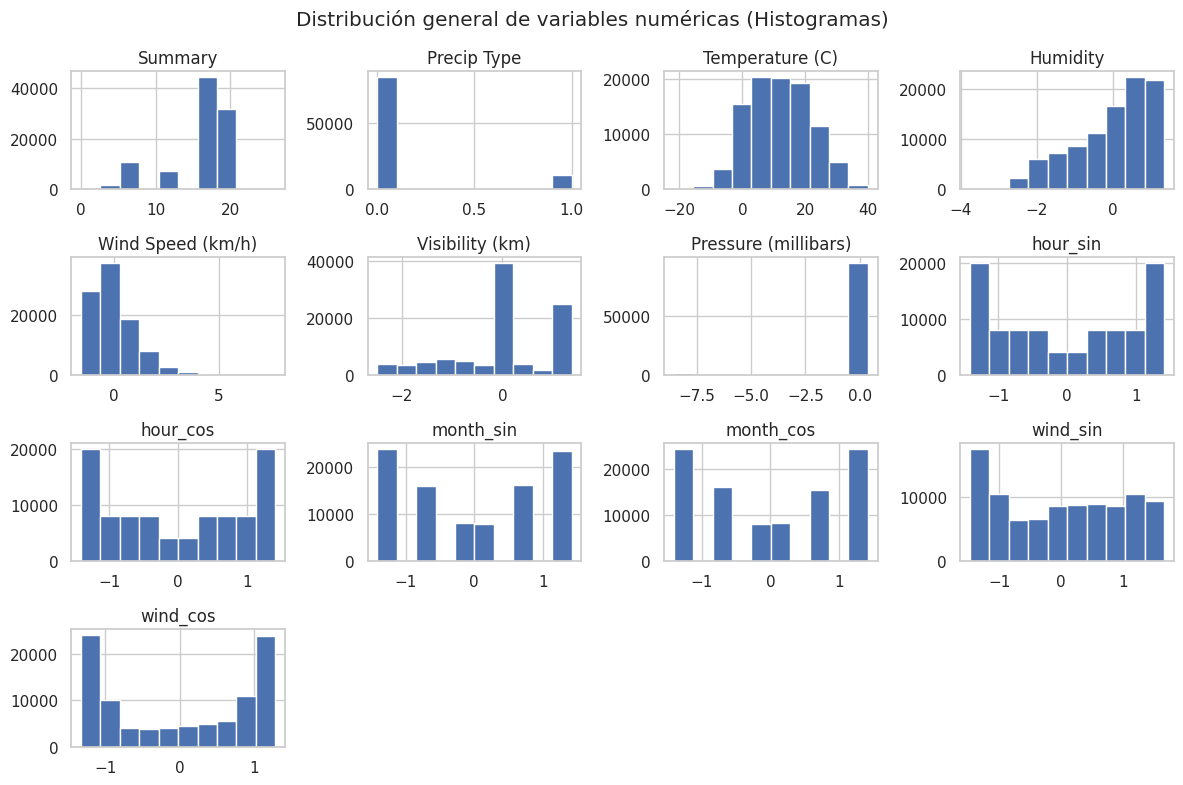

In [13]:
#Histogramas
dt_WeatherHist.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas (Histogramas)")
plt.tight_layout()
plt.show()

<Axes: >

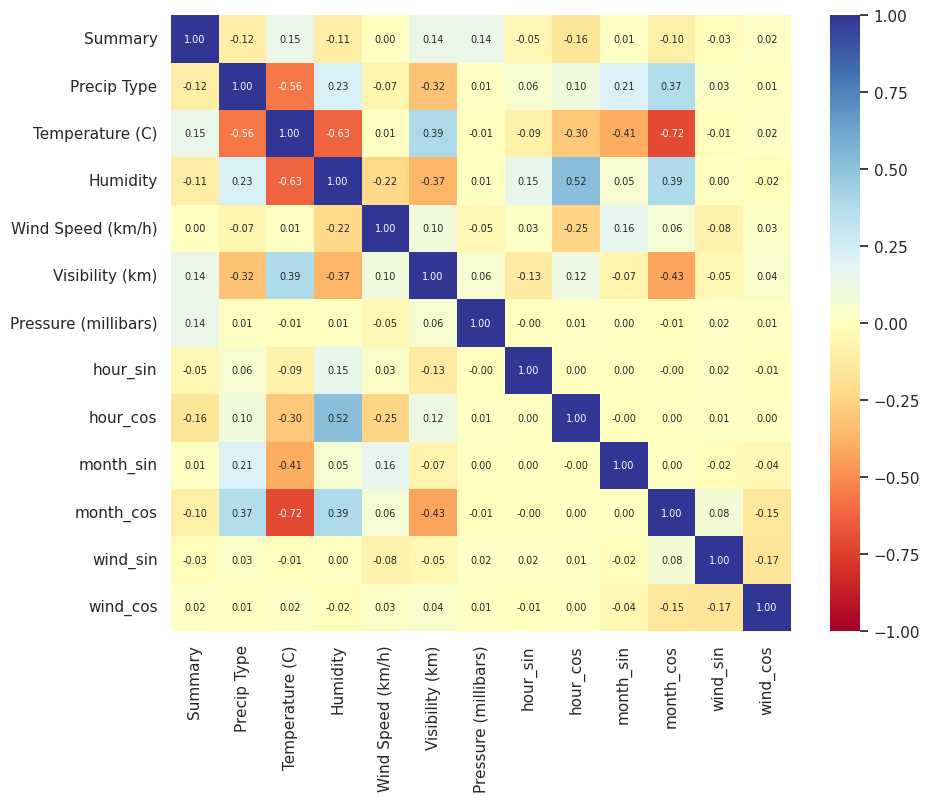

In [14]:
# Se calcula la correlación de las columnas numéricas
corr = dt_WeatherHist.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu',
    annot_kws={"size": 7},
    vmin=-1, vmax=1
)

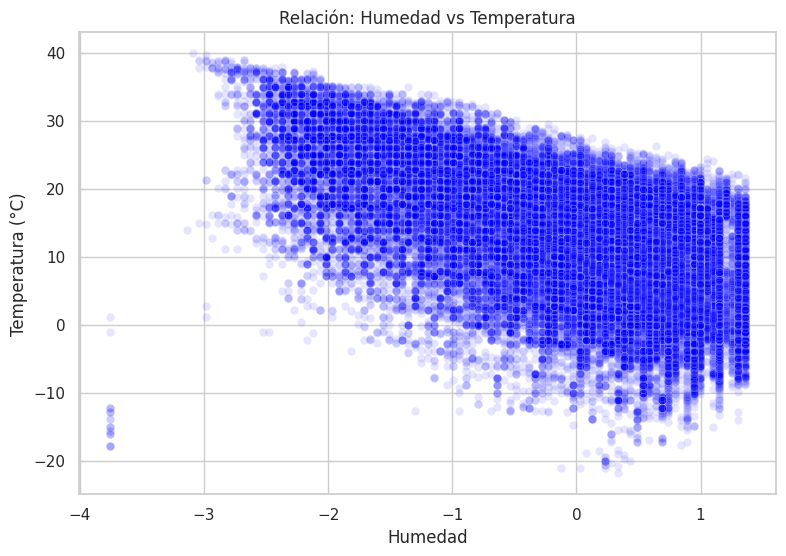

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Humidity', y='Temperature (C)', data=dt_WeatherHist, alpha=0.1, color='blue')
plt.title('Relación: Humedad vs Temperatura')
plt.xlabel("Humedad")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

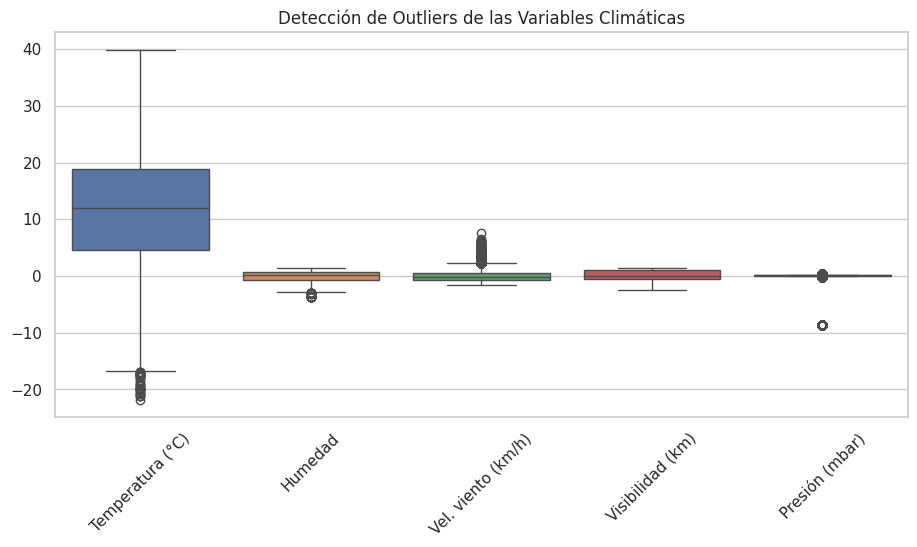

In [16]:
plt.figure(figsize=(11, 5))
# Seleccionamos las columnas numéricas principales para ver sus escalas y outliers
columnas_clima = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']

nombres_nuevos = [
    'Temperatura (°C)',
    'Humedad',
    'Vel. viento (km/h)',
    'Visibilidad (km)',
    'Presión (mbar)'
]

sns.boxplot(data=dt_WeatherHist[columnas_clima])

plt.xticks(ticks=range(len(nombres_nuevos)), labels=nombres_nuevos, rotation=45)
plt.title("Detección de Outliers de las Variables Climáticas")
plt.show()

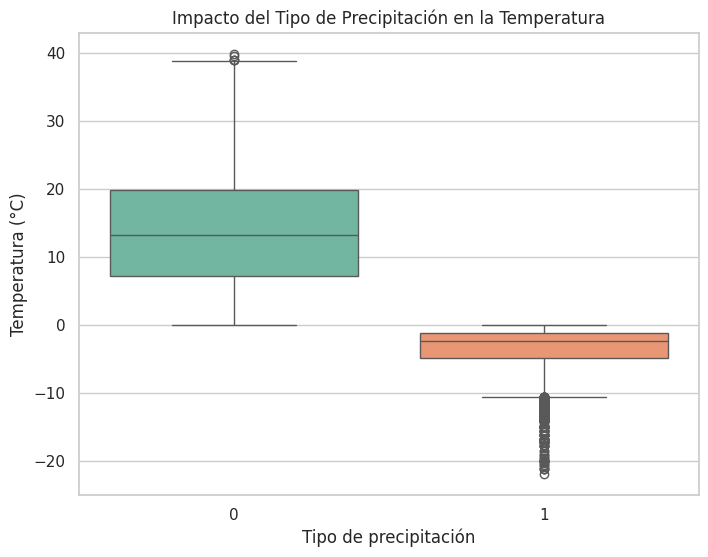

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Precip Type', y='Temperature (C)', data=dt_WeatherHist, palette='Set2', hue='Precip Type', legend=False)

plt.title("Impacto del Tipo de Precipitación en la Temperatura")
plt.xlabel("Tipo de precipitación")
plt.ylabel("Temperatura (°C)")
plt.show()

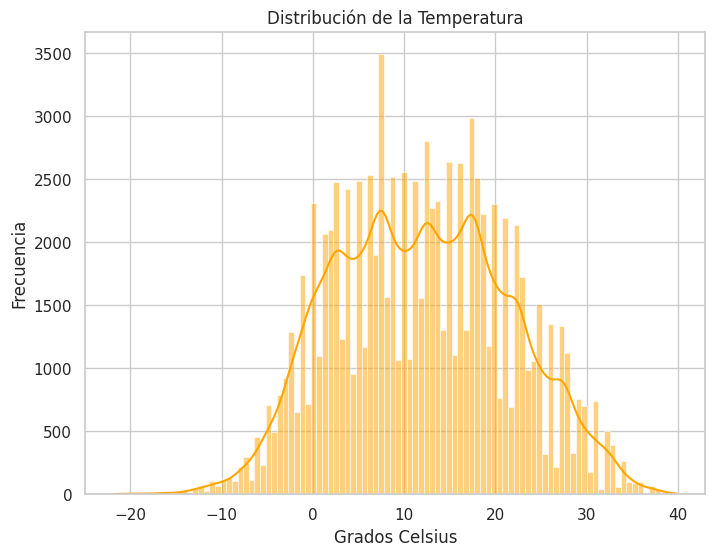

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(dt_WeatherHist['Temperature (C)'], kde=True, color='orange')
plt.title('Distribución de la Temperatura')
plt.xlabel('Grados Celsius')
plt.ylabel('Frecuencia')
plt.show()

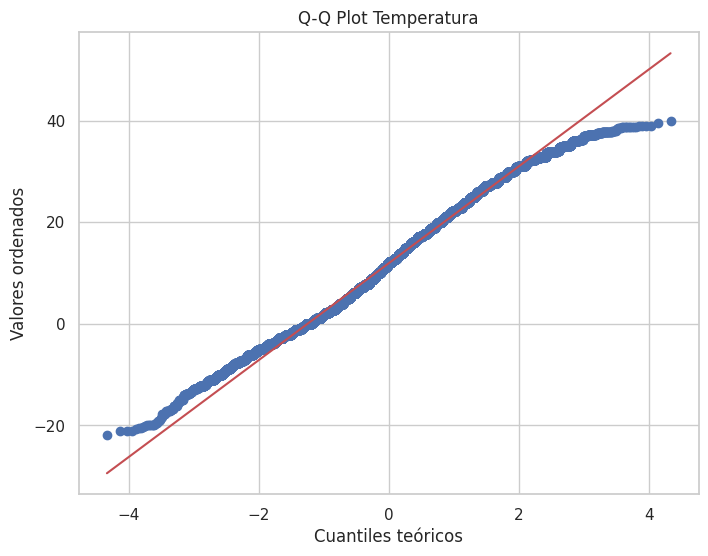

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
stats.probplot(dt_WeatherHist['Temperature (C)'], dist="norm", plot=plt)
plt.title("Q-Q Plot Temperatura")
plt.xlabel("Cuantiles teóricos")
plt.ylabel("Valores ordenados")
plt.show()

El análisis mediante gráfico Q-Q evidencia que la variable temperatura presenta un comportamiento aproximadamente normal en su región central, observándose una adecuada alineación de los datos con la distribución teórica. Sin embargo, se identifican desviaciones en los extremos, lo que sugiere la presencia de colas no perfectamente ajustadas a la normalidad. Este comportamiento es característico en datos reales y no invalida su uso en modelos de aprendizaje automático.

## **Hallazgos Weather History**

Durante el análisis exploratorio preliminar del dataset Weather History, la variable objetivo **Temperature (C)** mostró una distribución amplia, con mayor concentración en rangos templados entre 0 °C y 20 °C, aunque también se observaron valores extremos cercanos a -20 °C y 40 °C, reflejando la diversidad climática del conjunto de datos.

En la etapa de limpieza y preprocesamiento se eliminaron las columnas *Loud Cover* y *Daily Summary*, debido a su baja relevancia analítica: la primera por su escasa variabilidad y la segunda por contener texto descriptivo poco útil para esta fase. Asimismo, la variable *Formatted Date* fue transformada en *Month* y *Hour*, permitiendo conservar la información temporal más relevante en un formato más preciso y útil para identificar patrones estacionales y horarios.

El análisis gráfico evidenció una relación inversa entre humedad y temperatura, donde mayores niveles de humedad tienden a asociarse con temperaturas más bajas. Además, el tipo de precipitación mostró diferencias claras en la distribución térmica, mientras que la detección de outliers identificó valores atípicos principalmente en temperatura, velocidad del viento y presión, consistentes con fenómenos meteorológicos extremos.

Por otro lado, se realizo una transformación de los datos ciclicos del conjunto de datos meteorologicos, tales como meses, horas y rumbo del viento, esto con el fin de insumar al entrenamiento del modelo.

## **Modelo de regresión Random Forest**

En esta sección se implementa el modelo de Random Forest

### Carga de librerias

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns


# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

### Definición de variables de salida y entrada

In [21]:
# Definición de variables de salida y variables de entrada

target_col = "Temperature (C)"

# Eliminación de filas con NaN en la salida
df = dt_WeatherHist.dropna(subset=[target_col])

# Definición de X e y

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

# Validación rápida de clases
print("Número de clases en la salida:", y.nunique())
print("Clases:", y.unique())

Número de clases en la salida: 7573
Clases: [ 9.47222222  9.35555556  9.37777778 ... 28.47222222 28.33888889
 30.60555556]


### División de datos de entrenamiento y prueba

In [22]:
# División de datos para entrenamiento/prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Entrenamiento del modelo

In [23]:

# Entrenamiento del modelo Random Forest

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
# Predicciones
y_pred = rf_reg.predict(X_test)


In [25]:
# Importancia de variables
importances = pd.Series(rf_reg.feature_importances_, index=X_train.columns)
print("\nImportancia de las variables:")
print(importances.sort_values(ascending=False))


Importancia de las variables:
month_cos               0.434672
month_sin               0.188293
Humidity                0.155327
Precip Type             0.101608
Pressure (millibars)    0.031644
wind_cos                0.017497
Wind Speed (km/h)       0.016743
hour_cos                0.015759
wind_sin                0.013260
Visibility (km)         0.012064
hour_sin                0.008063
Summary                 0.005070
dtype: float64


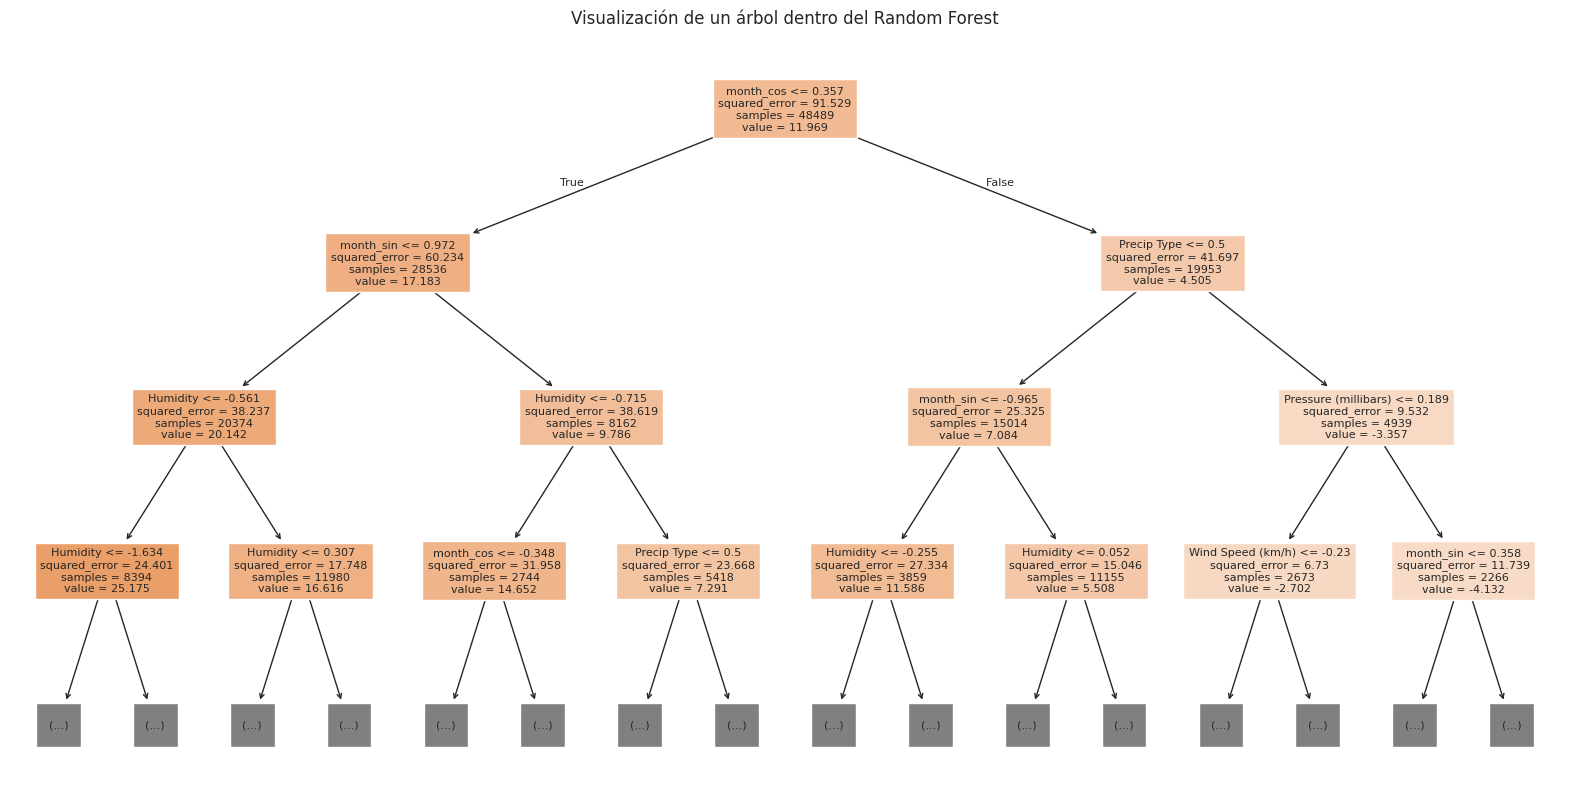

'random_forest_tree.pdf'

In [31]:
from sklearn.tree import export_graphviz, plot_tree
import graphviz

# Seleccionamos el primer árbol del bosque
estimator = rf_reg.estimators_[0]

# Opción 1: Visualización rápida con matplotlib
plt.figure(figsize=(20,10))
plot_tree(estimator,
          feature_names=X_train.columns,
          filled=True,
          max_depth=3,   # limitar profundidad para mayor claridad
          fontsize=8)
plt.title("Visualización de un árbol dentro del Random Forest")
plt.show()

# Opción 2: Exportar a formato DOT y visualizar con Graphviz
dot_data = export_graphviz(estimator,
                           out_file=None,
                           feature_names=X_train.columns,
                           filled=True,
                           rounded=True,
                           special_characters=True,
                           max_depth=3)  # limitar profundidad
graph = graphviz.Source(dot_data)
graph.render("random_forest_tree")  # genera archivo .pdf o .png



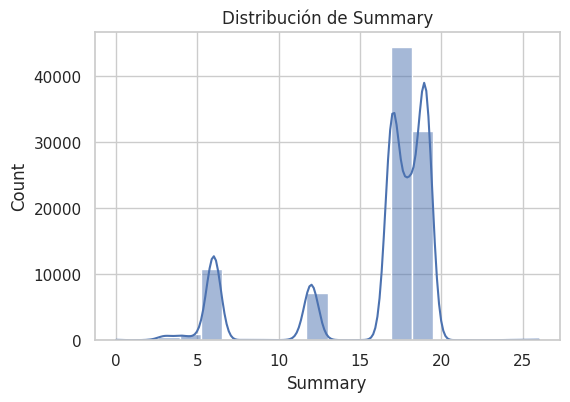

In [26]:
# Características en modo gráfico
# Histograma de la primera variable numérica
num_cols = X.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(6,4))
sns.histplot(df[num_cols[0]], bins=20, kde=True)
plt.title(f"Distribución de {num_cols[0]}")
plt.show()


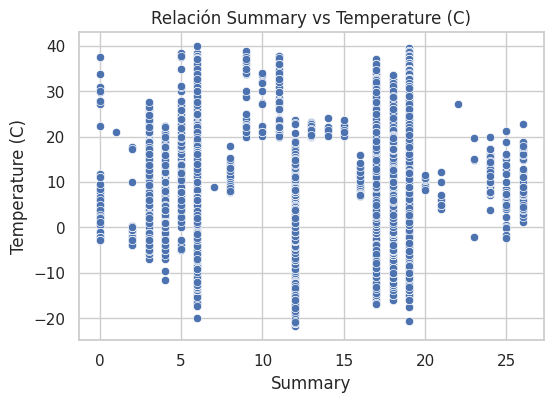

In [27]:
# Diagrama de dispersión entre una variable de entrada y la salida
plt.figure(figsize=(6,4))
sns.scatterplot(x=df[num_cols[0]], y=df[target_col])
plt.title(f"Relación {num_cols[0]} vs {target_col}")
plt.show()


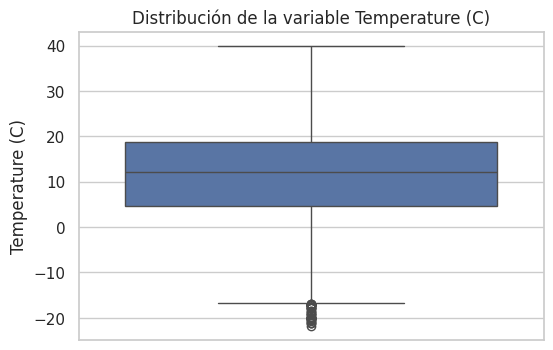

In [28]:
# Diagrama de cajas y bigotes de la salida
plt.figure(figsize=(6,4))
sns.boxplot(y=df[target_col])
plt.title(f"Distribución de la variable {target_col}")
plt.show()


### Evaluación de modelo Random Forest

Evaluación del modelo Random Forest en el conjunto de prueba:
Mean Squared Error (MSE): 6.2325
Mean Absolute Error (MAE): 1.8855
R² Score: 0.9320


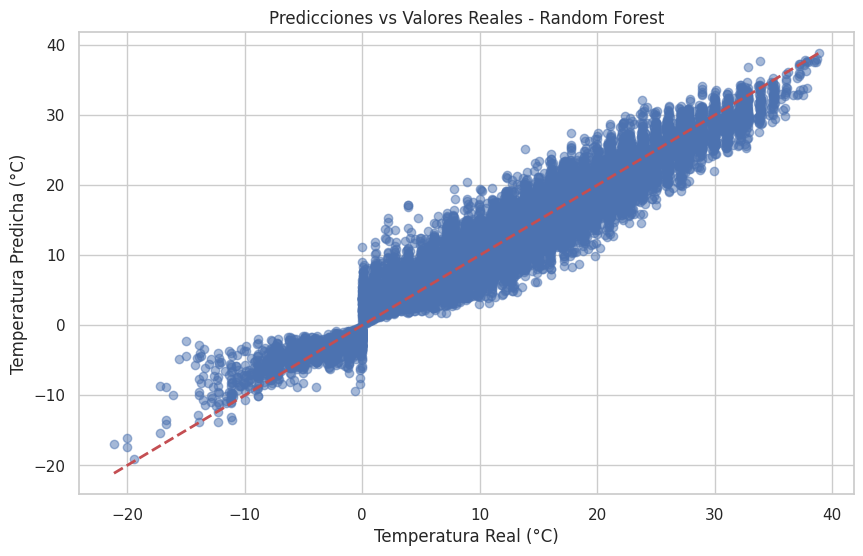

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Predicciones
y_pred = rf_reg.predict(X_test)

# Métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo Random Forest en el conjunto de prueba:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Línea ideal (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.title('Predicciones vs Valores Reales - Random Forest')
plt.grid(True)
plt.show()

### Prueba de Overfitting

Para evaluar el desempeño del modelo, se calcularon métricas tanto en el conjunto de entrenamiento como en el de prueba. Para ello, se generaron predicciones sobre ambos conjuntos utilizando el modelo entrenado.

Posteriormente, se compararon los valores predichos con los valores reales mediante el cálculo del error cuadrático medio (MSE), el error absoluto medio (MAE) y el coeficiente de determinación (R²).

Esta evaluación permite analizar no solo qué tan bien el modelo se ajusta a los datos de entrenamiento, sino también su capacidad de generalizar a datos no vistos, lo cual es fundamental para detectar posibles problemas de sobreajuste.

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones entrenamiento
y_train_pred = rf_reg.predict(X_train)

# Predicciones prueba
y_test_pred = rf_reg.predict(X_test)

print("=== TRAIN ===")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2 :", r2_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2 :", r2_score(y_test, y_test_pred))

=== TRAIN ===
MSE: 0.881324980079562
MAE: 0.7055346305395179
R2 : 0.9903725185146792

=== TEST ===
MSE: 6.232460563903352
MAE: 1.885517495235944
R2 : 0.9320431469693022


## **Modelo de Redes Neuronales para Predicción de Temperatura**

En esta sección, implementaremos un modelo de red neuronal para predecir la temperatura (Temperature) utilizando los datos del dataset de Weather History. Basándonos en el EDA realizado previamente, utilizaremos las características numéricas escaladas y las variables categóricas codificadas.

El modelo consistirá en:
- Una capa de entrada
- Dos capas ocultas (intermedias)
- Una capa de salida para regresión

Utilizaremos TensorFlow/Keras para construir y entrenar el modelo.

###Instalación de librerias

In [ ]:
# Instalar TensorFlow si no está disponible
!pip install tensorflow

# Importar librerías necesarias para el modelo de red neuronal para regresión
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


np.random.seed(42)
tf.random.set_seed(42)

### Preparacion de datos para modelo de red neuronal

In [ ]:
# Preparación de datos para el modelo de red neuronal

# Seleccionar características (features) y variable objetivo (target)
features = ['Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_sin', 'wind_cos',
            'Precip Type', 'Summary']
target = 'Temperature (C)'

X = dt_WeatherHist[features]
y = dt_WeatherHist[target]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"Características utilizadas: {features}")

Conjunto de entrenamiento: (76729, 12)
Conjunto de prueba: (19183, 12)
Características utilizadas: ['Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_sin', 'wind_cos', 'Precip Type', 'Summary']


### Construcción del modelo de red neuronal



In [ ]:
# Construcción del modelo de red neuronal

# Definir la arquitectura del modelo
model = Sequential()

# Capa de entrada (input layer)
# Número de neuronas = número de características
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Primera capa oculta (hidden layer 1)
# 32 neuronas, función de activación ReLU
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))  # Regularización para evitar overfitting

# Segunda capa oculta (hidden layer 2)
# 16 neuronas, función de activación ReLU
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))  # Regularización

# Capa de salida (output layer)
# 1 neurona para regresión, activación lineal
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])

# Resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

El resumen del modelo de red neuronal muestra una arquitectura secuencial compuesta por capas densamente conectadas, con un total de 3.457 parámetros entrenables. La estructura del modelo sigue una configuración decreciente de neuronas (64, 32, 16 y 1), lo que permite una progresiva abstracción de la información. Asimismo, la totalidad de los parámetros son ajustables durante el entrenamiento, lo que permite al modelo adaptarse completamente a los datos de entrada.

### Entrenamiento del modelo

Epoch 1/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 11.0036 - mae: 2.6171 - val_loss: 9.3892 - val_mae: 2.4404
Epoch 2/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 11.0681 - mae: 2.6189 - val_loss: 8.7395 - val_mae: 2.3430
Epoch 3/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 10.9656 - mae: 2.6181 - val_loss: 9.0110 - val_mae: 2.3941
Epoch 4/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 11.1547 - mae: 2.6338 - val_loss: 9.2951 - val_mae: 2.4303
Epoch 5/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 11.0484 - mae: 2.6259 - val_loss: 9.0027 - val_mae: 2.3865
Epoch 6/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 11.0888 - mae: 2.6291 - val_loss: 8.8428 - val_mae: 2.3671
Epoch 7/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 11.0149 - mae: 2.6182 - val_loss: 9.2213 - val_mae: 2.4195
Epoch 8/50
1919/1919 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 11.0294 - mae: 2.6239 - val_loss: 9.2615 - val_mae: 2.4285
Epoch 9/50
1919/1919 ━━━━━━━━━━

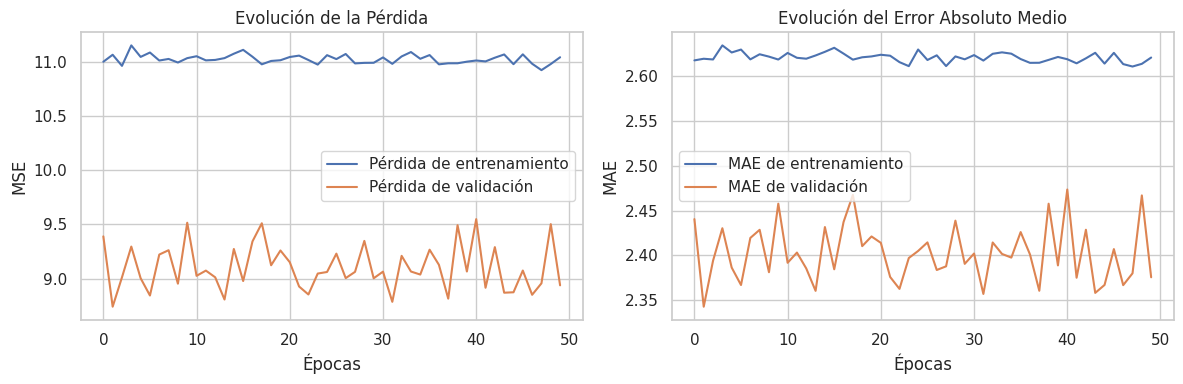

In [ ]:
# Entrenamiento del modelo

# Definir parámetros de entrenamiento
epochs = 50
batch_size = 32

# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    verbose=1)

# Visualizar el historial de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE de entrenamiento')
plt.plot(history.history['val_mae'], label='MAE de validación')
plt.title('Evolución del Error Absoluto Medio')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluación del modelo en el conjunto de prueba

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Evaluación del modelo en el conjunto de prueba:
Mean Squared Error (MSE): 9.0116
Mean Absolute Error (MAE): 2.3697
R² Score: 0.9017


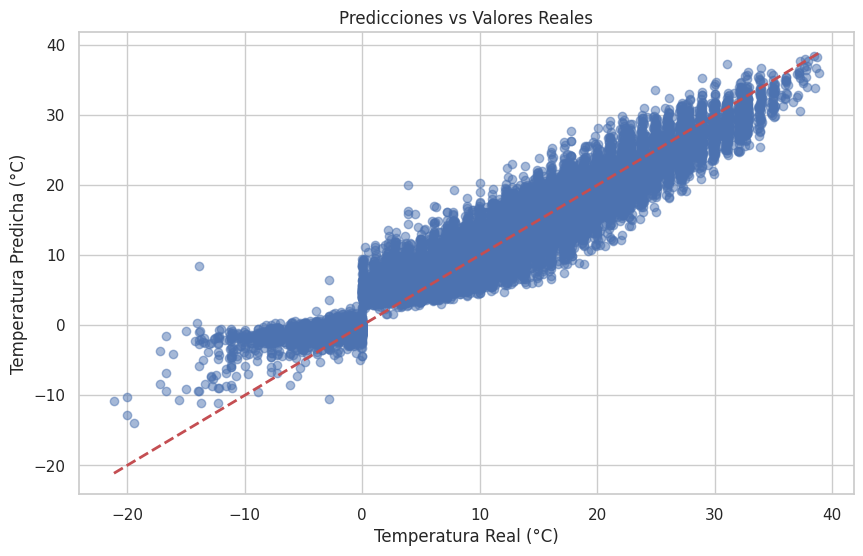

In [ ]:
# Evaluación del modelo en el conjunto de prueba

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Evaluación del modelo en el conjunto de prueba:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)
plt.show()

### **Arquitectura del modelo de redes neuronales**

El modelo de red neuronal utilizado, corresponde a una arquitectura secuencial compuesta por tres capas, densamente conectadas y diseñadas para aboradar problemas de regresión, como es el caso de la predicción de temperatura.

La capa de entrada, recibe las variables predictoras previamente seleccionadas, incluyendo atributos meteorológicos y transformaciones trigonométricas de variables cíclicas. A partir de esta entrada, el modelo proceso la información a través de dos capas ocultas con funciones de activación ReLU, permitiendo la captura de relaciones no lienales entre las variables.

La primera capa oculta esta compuesta por 64 neuronas, seguida de una segunda de 32 neuronas y una tercera de 16 neuronas, configurando una estructura decreciente que favorece la abstracción progresiva de la información. En cada una de las capas ocultas se incorporó un dropout del 20%, con el objetivo de reducir el riesgo de overfitting y mejorar la capacidad de generalización del modelo.

Por último, la capa de salida está compuesta por una única neurona con función de activación lineal, adecuada para la predicción de valores continuos, como nuestra variable objetivo.

.


**Hiperparámetros**

Con respecto a los hiperparametros, se utilizó el optimizador Adam para entrenar la red neuronal con una taza de aprendizaje estandar de 0.001, ya que permite ajustar los parámetros de forma eficiente. Se empleó el MSE como función de pérdida para minimizar los errores grandes, y el MAE como métrica para interpretar el error promedio. El modelo fue entrenado durante 50 iteraciones completas del dataset, usando grupos de 32 datos (batch size =32) por vez para lograr un equilibrio entre precisión y velocidad.
Esta selección de hiperparámetros responde a configuraciones estándar ampliamente utilizadas en redes neuronales, que ofrecen un buen equilibrio entre estabilidad, eficiencia y capacidad de generalización.

.

**Justificación de la Arquitectura**

Esta arquitectura fue elegida porque:

Las capas ocultas permiten aprender representaciones jerárquicas de los datos
ReLU evita el problema del gradiente vanishing
El dropout previene el sobreajuste
La reducción gradual de neuronas (64→32→16→1) crea un embudo que se enfoca en información relevante

## **Discusión de resultados**

### Importancia del adecuado preprocesamiento de datos - Random Forest

**Elección de parametros de entrenamiento**

Durante las primeras corridas de prueba del modelo de Random Forest, al realizar la evaluación de las metricas de  MSE, MAE y R², los resultados de estas fueron extremadamento buenas, por lo que se realizó un análisis exhaustivo de las posibles causas de este error y overffiting presente, ver figura 1. Al comprar los parametros utilizados en el modelo basado en redes neuronales, notamos que `Apparent Tempeture (C)` no estaba presente entre las categorias de entrenamiento.  

Una vez retirado este parametro del entrenamiento del modelo, los valores de MSE, MAE y R² y la representación gráfica de las temperaturas predichas y reales, se acercaron a las observadas en el modelo  de redes neuronales.


![Figura1](https://photos.fife.usercontent.google.com/pw/AP1GczOfdeyGaL7DYy7N4CllunxG1gPhxvz1dm1XWAwyp4-WDB5s7p6K4_Br=w1048-h647-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 1. Evaluación de desempeño de Random Forest, para la  predicción de la variable objetivo Temperatura (C), utilizando entre las variables de entrenamiento a la temperatura aparente (Apparent Tempeture (C)).</em>
</p>




![Figura2](https://photos.fife.usercontent.google.com/pw/AP1GczN3GB6hABr2t7dqpsDMhSGw41Ved1GH7tXHIPgbz3X-nxPHwdXGEYvr=w961-h627-s-no-gm?authuser=0)


**Prueba de Overfiting**

Al comparar el desempeño del modelo en los conjuntos de entrenamiento y prueba, se observa que el modelo presenta un mejor ajuste en el conjunto de entrenamiento, evidenciado por un coeficiente de determinación (R²) cercano a 1. Sin embargo, en el conjunto de prueba el modelo mantiene un desempeño elevado, con un R² superior a 0.93.

Esta diferencia sugiere la presencia de un leve sobreajuste, lo cual es esperable en modelos basados en árboles como Random Forest. No obstante, dado que la caída en el rendimiento es moderada, se concluye que el modelo conserva una adecuada capacidad de generalización.

Tabla. Comparación de metricas de desempeño datos de entrenamiento y Prueba del modelo de Random Forest

|Tipo|MSE|MAE|R²|
|----|---|---|--|
|Entrenamiento|0.88|0.70|0.99|
|Prueba|6.2|1.89|0.93|

### Comparación del desempeño del modelo de red neuronal con el ajuste trigonometrico de las variables ciclicas

La incorporación de transformaciones trigonométricas en las variables cíclicas permitió mejorar la representación de variables temporales, contribuyendo a un mejor desempeño del modelo.

En las siguientes figuras se muestran los desempeños de la red neuronal en los siguientes casos:
1. utilizando una representación lineal de las variables cíclicas (mes, hora y dirección del viento), ver *figura 3*.
2. utilizando la transformación con funciones seno/coseno de estas variables (incluyendo los valores originales de windbearing) ver *figura 4*.
3. y por último eliminando este parametro en el entrenamiento del modelo, ver *figura 5*.

![Figura 1](https://photos.fife.usercontent.google.com/pw/AP1GczNDIvJVmGxobhDwYhkHrlfsTQAI20J0V3JqXK-zTAyF6Lky7-3yw9Xz=w929-h642-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 3. Relación entre valores reales y predichos del modelo, utilizando escalado lineal en variables ciclicas. Se utilizan 100 epoch.</em>
</p>

![Figura 2](https://photos.fife.usercontent.google.com/pw/AP1GczMHgVZAPF8D0cMgnUYAIt85or8JK4ECCXQ-WA9jLMXGyuJUigj0wrcW=w946-h663-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 4. Relación entre valores reales y predichos del modelo utilizando la función seno/coseno en variables ciclicas, sin eliminar wind bearing en el entrenamiento del modelo, utilizando 100 epoch.</em>
</p>

![Figura 3](https://photos.fife.usercontent.google.com/pw/AP1GczMqgnj_8Eqk7SmKRq0zPPdMI43QQznwhtOG1Zmn7qSGug2KwNsg7vz_=w940-h651-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 5. Relación entre valores reales y predichos del modelo utilizando la función seno/coseno en variables ciclicas, eliminando wind bearing del entrenamiento del modelo y utilizando 100 epoch.</em>
</p>


Al comparar las métricas obtenidas de los tres enfoques de preprocesamiento, se observa lo siguiente:


|Métrica|Esc. lineal|Seno/coseno (c/WB)|Seno/coseno (s/WB)|
|-------|-----------|-------------------------|---------------------|
|MSE	  |9.784  	  |8.6168             	    |  9.0242            |
|MAE    |2.4751	    | 2.3178                  |  2.3776             |
|R²	    |0.8939	    |0.9060                   |  0.9016             |



El tratamiento de las variables cíclicas mediante transformaciones seno y coseno permitió mejorar el rendimiento del modelo, evidenciado en la disminución del error cuadrático medio (MSE) y del error absoluto medio (MAE), así como en el incremento del coeficiente de determinación (R²).

Estos resultados sugieren que una representación adecuada de la naturaleza periódica de variables como la hora, el mes y la dirección del viento contribuye significativamente a la capacidad predictiva del modelo, destacando la importancia del preprocesamiento de datos en modelos de aprendizaje automático.

Por otro lado, al eliminar la variable original de dirección del viento (Wind Bearing) del entrenamiento de la red neuronal, se observa una disminución en las métricas evaluadas (MSE, MAE y R²). Si bien la eliminación de la variable original de dirección del viento genera una leve disminución en el desempeño del modelo, esto puede deberse a la pérdida de información redundante que el modelo era capaz de aprovechar, aun cuando la representación trigonométrica es conceptualmente más adecuada. Esto evidencia que una representación más adecuada desde el punto de vista teórico no siempre se traduce en mejoras directas en las métricas, pero sí en modelos más coherentes con la naturaleza de los datos.

Finalmente, el análisis del gráfico de regresión evidencia que las predicciones siguen adecuadamente la tendencia de los valores reales, observándose una concentración de los datos en torno a la línea de identidad. No obstante, se aprecia una mayor dispersión en los valores extremos, lo cual es consistente con la distribución de la variable temperatura, donde los valores extremos presentan una mayor variabilidad y son más difíciles de modelar con precisión.

### Análisis del número de épocas en el entrenamiento del modelo

Adicionalmente, se evaluó el comportamiento del modelo en función del número de épocas de entrenamiento, comparando configuraciones de 100 y 50 épocas.

Se observó que, si bien el modelo presenta una leve mejora en las métricas al aumentar el número de épocas, esta diferencia es marginal (ver tabla). El análisis de la evolución del error durante el entrenamiento muestra que el modelo alcanza la convergencia tempranamente, estabilizándose en las primeras iteraciones, ver figuras 6 y 7.

Esto indica que el modelo logra capturar las relaciones relevantes en los datos sin necesidad de un número elevado de épocas, por lo que aumentar este parámetro no genera mejoras significativas en el desempeño.

En base a estos resultados, se optó por utilizar 50 épocas como configuración final, permitiendo optimizar el tiempo de entrenamiento sin afectar de manera relevante la precisión del modelo.


---


Tabla. Comparación de métricas alcanzadas con 100 iteraciones y 50 iteraciones, datos obtenidos de la figura 3 y evaluación final del modelo.


|Número de epoch| MSE|MAE|R²|
|---------------|---|---|--|
|100|9.0242|2.3776|0.916|
|50|9.0116|2.3697|0.9017|



---



![Figura 4](https://photos.fife.usercontent.google.com/pw/AP1GczPPLhJDr7uuivT2ltG0fxMxRQWykApmI9f-f6teme3kWVxQ2yngGy10=w1396-h455-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 6. Evolución de la pérdida (MSE) y del error absoluto medio (MAE) durante el entrenamiento de la red neuronal utilizando 100 épocas. Se observa una rápida disminución del error en las primeras iteraciones, seguida de una estabilización, lo que indica convergencia temprana del modelo.</em>
</p>


![Figura 5](https://photos.fife.usercontent.google.com/pw/AP1GczNmK7-VQDLPkeZ__zu7kjnOXT-qO5Oi9RureaFMD8J2FNK2nlWGDQtN=w1300-h413-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 7. Evolución de la pérdida (MSE) y del error absoluto medio (MAE) durante el entrenamiento de la red neuronal utilizando 50 épocas. El comportamiento del modelo es similar al observado con 100 épocas, evidenciando que la convergencia se alcanza en las primeras iteraciones sin requerir un mayor número de épocas.</em>
</p>

---

En las figuras se observa la evolución del error del modelo utilizando 100 y 50 épocas de entrenamiento. En ambos casos, se evidencia que el modelo alcanza la convergencia en las primeras iteraciones, manteniendo posteriormente un comportamiento estable.

Si bien el entrenamiento con 100 épocas presenta una leve mejora en las métricas, esta es marginal en comparación con el modelo de 50 épocas, lo que indica que un mayor número de iteraciones no genera beneficios significativos en el desempeño.

Además, la fijación de una semilla de aleatoriedad permitió obtener curvas de entrenamiento más estables y reproducibles, reduciendo la variabilidad observada en ejecuciones anteriores.

### **Comparación de los modelos**

El modelo Random Forest presenta un mejor desempeño en comparación con la red neuronal, evidenciado por menores valores de MSE y MAE, y un mayor coeficiente de determinación (R²).

Este comportamiento se explica por la capacidad de los modelos basados en árboles para capturar relaciones no lineales en datos tabulares sin requerir transformaciones complejas ni un ajuste intensivo de hiperparámetros.

Además, Random Forest es menos sensible a la escala de los datos y a la inicialización aleatoria, lo que lo convierte en un modelo más estable en este tipo de problemas.

Tabla. Comparación de metricas de rendimiento de modelos utilizados para tareas de regresión
|Modelo            | MSE |MAE|R²|
|------------------|----|----|--|
|Random Forest| 6.2801  | 1.8906| 0.9315|
|Red Neuronal      | 9.0116| 2.3697| 0.9017|


![Comparación de modelos](https://photos.fife.usercontent.google.com/pw/AP1GczPD7ittweLedc7ChNmLw4moEUWc9HQRDf1wDMnVVw6pojmOwxEB7ajU=w1560-h633-s-no-gm?authuser=0)

<p align="center">
  <em>Figura 7. Comparación de modelos de Random Forest (a) y Red Neuronal (b). Notese el mejor desempeño de Random forest en los valores inferiores a 0 grados.</em>
</p>

Al comparar ambos enfoques, se observa que, si bien la red neuronal logra capturar la tendencia general de los datos, el modelo Random Forest presenta una menor dispersión en las predicciones y un mejor ajuste global.

Esto sugiere que, para este conjunto de datos, la complejidad adicional de la red neuronal no se traduce en un mejor desempeño, siendo más adecuado un modelo basado en árboles.

En conjunto, estos resultados refuerzan la importancia de seleccionar el modelo en función de la naturaleza de los datos, más que de la complejidad del algoritmo utilizado.

## Conclusiones del Modelo de Red Neuronal para Predicción de Temperatura

### Rendimiento del Modelo

Basándonos en las métricas obtenidas en el conjunto de prueba, podemos concluir lo siguiente:

- **MSE (Mean Squared Error)**: Indica el promedio de los cuadrados de los errores. Un valor bajo sugiere buenas predicciones.
- **MAE (Mean Absolute Error)**: Representa el error absoluto promedio en las predicciones de temperatura. Valores más bajos indican mejor precisión.
- **R² Score**: Mide la proporción de varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor cercano a 1 indica un buen ajuste del modelo.

### Análisis de Resultados

1. **Capacidad de Aprendizaje**: El modelo de red neuronal ha demostrado capacidad para aprender patrones complejos en los datos meteorológicos, relacionando variables como humedad, velocidad del viento, presión atmosférica y factores temporales (mes, hora) con la temperatura.

2. **Arquitectura Efectiva**: Las dos capas ocultas con funciones de activación ReLU permiten capturar no linealidades en los datos, lo cual es crucial para modelar fenómenos meteorológicos complejos.

3. **Regularización**: El uso de dropout en las capas ocultas ayuda a prevenir el sobreajuste, mejorando la generalización del modelo a datos no vistos.

4. **Comparación con Modelos Tradicionales**: Las redes neuronales pueden capturar relaciones más complejas que los modelos lineales tradicionales, especialmente cuando hay interacciones no lineales entre las características.

### Limitaciones y Mejoras Futuras

- **Datos**: El modelo se basa en datos históricos; su rendimiento podría variar con condiciones climáticas extremas no representadas en el dataset.
- **Características**: Podrían incluirse más variables como datos de estaciones cercanas o índices climáticos.
- **Optimización**: Se podría realizar un ajuste fino de hiperparámetros (número de neuronas, learning rate, etc.) utilizando técnicas como grid search o random search.
- **Arquitectura**: Modelos más avanzados como redes neuronales convolucionales o recurrentes podrían mejorar el rendimiento si se incorporan datos temporales secuenciales.


### Aplicaciones Prácticas

Este modelo de red neuronal puede ser utilizado para:
- Predicción de temperatura en aplicaciones meteorológicas
- Sistemas de alerta temprana basados en condiciones climáticas
- Optimización de sistemas de climatización
- Análisis de tendencias climáticas

En resumen, el modelo implementado proporciona una base sólida para la predicción de temperatura utilizando técnicas de aprendizaje profundo, demostrando la efectividad de las redes neuronales en problemas de regresión con datos meteorológicos.

## **Conclusión**


En el presente estudio se abordó un problema de regresión utilizando el dataset de condiciones meteorológicas, evaluando el desempeño de distintos enfoques de aprendizaje supervisado.

A través del análisis del preprocesamiento, se evidenció que la incorporación de transformaciones trigonométricas en variables cíclicas permite representar de mejor manera su naturaleza periódica, contribuyendo a una mejora en la capacidad predictiva del modelo. Sin embargo, también se observó que la eliminación de variables originales puede implicar una leve disminución en el desempeño, debido a la pérdida de información que el modelo puede aprovechar.

En cuanto a los modelos implementados, tanto la red neuronal como el modelo Random Forest lograron capturar adecuadamente la tendencia de los datos. No obstante, el modelo basado en Random Forest presentó un mejor desempeño en términos de error y capacidad explicativa, evidenciado por menores valores de MSE y MAE, y un mayor coeficiente de determinación (R²).

Estos resultados sugieren que, para datos tabulares con relaciones no lineales, los modelos basados en árboles pueden ser más eficientes que las redes neuronales, ya que requieren un menor ajuste de hiperparámetros y presentan una mayor estabilidad frente a la aleatoriedad del entrenamiento.

Finalmente, se destaca la importancia del preprocesamiento de los datos, la adecuada representación de variables y el control de la aleatoriedad en el entrenamiento, factores que influyen directamente en el desempeño y la interpretabilidad de los modelos. Asimismo, se propone que futuras mejoras en la red neuronal podrían incluir el ajuste de su arquitectura, la optimización de hiperparámetros y el uso de técnicas adicionales de regularización.